# Bugzilla 缺陷情报：主题挖掘 + 去重检索 + LLM 抽取评估 · 开发版（development）

> 这是**开发阶段**的独立 notebook：一步步跑、看中间结果，逻辑稳定后再收敛进 `pipeline.py`、对外展示用 `showcase.ipynb`。本 notebook 所有逻辑**内联**，方便边写边验证。

**数据**：Mozilla Bugzilla 公开缺陷（Firefox / Core / Thunderbird），共 **13,019** 条 bug，其中 **4,987 对** RESOLVED DUPLICATE 的 `dupe_of` 关系是**去重检索的硬标签（ground truth）**。93% 的 bug 带有 reporter 撰写的 description。抓取脚本见 `download_bugzilla.py`。

**这个项目回答三个问题**：
1. 海量 bug 反复在报告哪些**主题**？（无监督聚类）
2. 一条新 bug 提交时，能否自动找出它**重复于哪条已有 bug**？（语义去重检索 —— headline，有硬标签）
3. LLM 从 bug 文本里抽出的结构化字段（area / severity / kind）**可信吗**？（自纠错抽取 + LLM-as-judge，用 Cohen's κ 对人工标注校准）

主线 8 步：加载 → embedding → 聚类主题 → 统计(Wilson CI) → 抽取 agent(LangGraph 工具调用 + 真实 MCP 接地) → auto-rater×κ → **去重检索(hit@k / MRR)** → readout。

## 各步数据量地图（为什么每步用量不同）

不同步骤刻意用**不同的数据量**——原则是：**便宜的操作（向量 / 聚类 / 统计）铺全库，贵的操作（LLM 抽取 / 人工标注）只取小样本**。

| 步骤 | 用量 | 口径 / 为什么 |
|---|---|---|
| Step 1 加载 | 全库 **13,019** | 语料基数 |
| Step 2 Embedding | 全库 **13,019** | 每条都要向量；ChromaDB 缓存，重跑零成本 |
| Step 3 聚类 | **fit 全库 13,019**；选 k 的 silhouette 仅 **3,000 采样** | 簇标签要覆盖全库；silhouette ~O(n²)，采样只为**选超参 k** |
| Step 4 主题占比 (Wilson CI) | 全库 **13,019** | 百分比要对全库有代表性 |
| Step 5 抽取 agent | 仅 **50 条**（`desc_words≥40`） | 每条要跑 检索+LLM 生成+critique+重试+去重 flag，贵而慢，只为演示 yield |
| Step 6 auto-rater / κ | **50 条**（与 Step 5 同批） | 人工标注最贵，50 条够估 Cohen's κ |
| Step 7 去重检索 | **4,987** 硬标签对 | 仅这些 bug 有 `dupe_of` ground truth |

In [82]:
import os, sys, json, time
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
oai = OpenAI()                        # 读 .env 里的 OPENAI_API_KEY

EMBED_MODEL = "text-embedding-3-small"
CHAT_MODEL  = "gpt-4o"
CHROMA_PATH, CHROMA_COLLECTION = "chroma_db", "bugzilla"
EXTRACT_N, SEED = 50, 42              # 抽取评估的样本量；固定随机种子保证可复现
MAX_ATTEMPTS = 3                      # 自纠错最多重试次数
TEXT_MAX_CHARS = 8000                 # embed 输入 + Chroma documents 统一截断长度
pd.set_option("display.max_colwidth", 100)
print("setup ok")

setup ok


## Step 1 · 加载语料

`bugs.csv` 每行一个 bug；`dup_pairs.csv` 是 `(重复bug_id, 主bug_id)` 硬标签。
把每个 bug 拼成一段文本：`[component] summary + description`。component 前缀帮助 embedding 区分子系统。

In [83]:
bugs = pd.read_csv("bugs.csv")
pairs = pd.read_csv("dup_pairs.csv")

def make_text(r):
    comp = str(r.get("component") or "").strip()
    summ = str(r.get("summary") or "").strip()
    desc = str(r.get("description") or "").strip()
    head = f"[{comp}] {summ}" if comp else summ
    return (head + "\n" + desc).strip() if desc and desc != "nan" else head

bugs["text"] = bugs.apply(make_text, axis=1)
bugs["desc_words"] = bugs["description"].fillna("").astype(str).str.split().str.len()
bugs = bugs.reset_index(drop=True)
print(f"bugs: {len(bugs):,} | dup pairs: {len(pairs):,} | masters: {pairs.master_id.nunique():,}")
print(f"roles: {bugs.role.value_counts().to_dict()}")
print(f"description coverage: {(bugs.desc_words>0).mean():.1%} | desc words median (non-empty): {bugs.loc[bugs.desc_words>0,'desc_words'].median():.0f}")
bugs[["id", "component", "role", "summary"]].head(3)

bugs: 13,019 | dup pairs: 4,987 | masters: 3,549
roles: {'dup': 5000, 'corpus': 4745, 'master': 3274}
description coverage: 93.3% | desc words median (non-empty): 91


,id,component,role,summary
0,11040,Filters,master,"Allow filters to control biff UI (i.e. only notify me of ""important"" messages)"
1,12306,Backend,master,Message notes/annotations
2,18764,Networking,master,Full rfc2557 MHTML multipart/related support in BROWSER


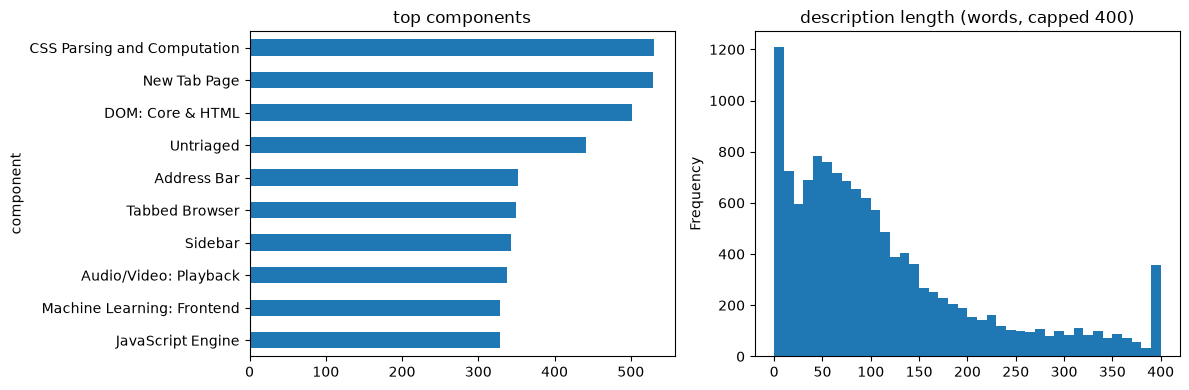

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bugs["component"].value_counts().head(10).plot(kind="barh", ax=ax[0], title="top components").invert_yaxis()
bugs["desc_words"].clip(upper=400).plot(kind="hist", bins=40, ax=ax[1], title="description length (words, capped 400)")
plt.tight_layout(); plt.show()

## Step 2 · Embedding + 向量库（缓存）

每个 bug 文本 → 1536 维向量（OpenAI `text-embedding-3-small`）。存进 ChromaDB 持久化：
用 **bug id 作 key**，方便后面 Step 7 按硬标签对齐。重跑命中缓存，零重复成本。

In [85]:
import chromadb
client = chromadb.PersistentClient(path=CHROMA_PATH)
col = client.get_or_create_collection(name=CHROMA_COLLECTION, metadata={"hnsw:space": "cosine"})

ids = bugs["id"].astype(str).tolist()
texts = bugs["text"].tolist()

existing = set(col.get(ids=ids)["ids"])                     # 已缓存的 id
todo = [i for i, id_ in enumerate(ids) if id_ not in existing]
print(f"{len(existing):,} cached, {len(todo):,} to embed")

BATCH = 500
for s in range(0, len(todo), BATCH):
    chunk = todo[s:s + BATCH]
    resp = oai.embeddings.create(model=EMBED_MODEL, input=[texts[i][:TEXT_MAX_CHARS] for i in chunk])
    col.upsert(ids=[ids[i] for i in chunk],
               embeddings=[e.embedding for e in resp.data],
               documents=[texts[i][:TEXT_MAX_CHARS] for i in chunk])
    print(f"  embedded {min(s+BATCH, len(todo)):,}/{len(todo):,}")
print("embedding done")

13,019 cached, 0 to embed
embedding done


In [86]:
# 按 bugs 的顺序取回向量，保证和 DataFrame 行对齐
res = col.get(ids=ids, include=["embeddings"])
id2vec = dict(zip(res["ids"], res["embeddings"]))
emb = np.array([id2vec[i] for i in ids], dtype=np.float32)
print("emb", emb.shape, "| L2 norm mean ≈", round(float(np.linalg.norm(emb, axis=1).mean()), 3),
      "(OpenAI 已归一化，cosine == 点积)")

emb (13019, 1536) | L2 norm mean ≈ 1.0 (OpenAI 已归一化，cosine == 点积)


## Step 3 · 聚类主题（silhouette 选 k）

无监督聚类看 bug 分哪些主题。扫一段 k，用 silhouette 挑最佳；再让 LLM 给每个簇起名。

> 注意：高维文本 embedding 的 silhouette 绝对值天然偏低（主题相互重叠、边界模糊），这是文本聚类的常态。聚类在这里是**探索 / 分主题**工具，**不是本项目的 headline**——headline 是 Step 7 有硬标签的去重检索。

  k= 8  silhouette=0.026
  k=10  silhouette=0.028
  k=12  silhouette=0.025
  k=14  silhouette=0.031
  k=16  silhouette=0.032
  k=18  silhouette=0.033
  k=20  silhouette=0.033
  k=22  silhouette=0.025
  k=24  silhouette=0.026
best k = 18 (silhouette=0.033)


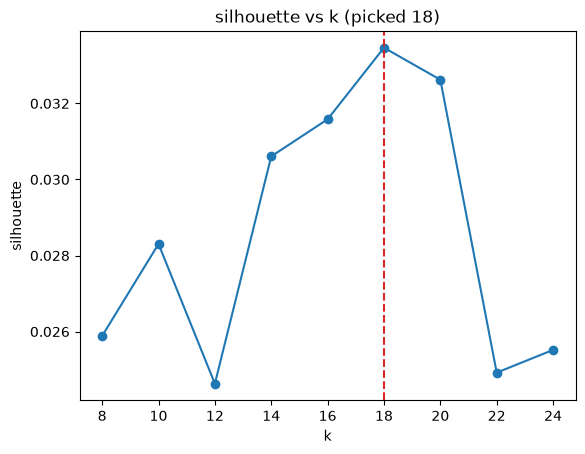

In [87]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rng = np.random.default_rng(SEED)
sidx = rng.choice(len(emb), size=min(3000, len(emb)), replace=False)   # 采样算 silhouette 更快
scores = {}
for k in (8, 10, 12, 14, 16, 18, 20, 22, 24):
    lab = KMeans(n_clusters=k, random_state=SEED, n_init="auto").fit_predict(emb[sidx])
    scores[k] = float(silhouette_score(emb[sidx], lab))
    print(f"  k={k:>2}  silhouette={scores[k]:.3f}")
best_k = max(scores, key=scores.get)
print(f"best k = {best_k} (silhouette={scores[best_k]:.3f})")
plt.plot(list(scores), list(scores.values()), "o-"); plt.axvline(best_k, color="C3", ls="--")
plt.xlabel("k"); plt.ylabel("silhouette"); plt.title(f"silhouette vs k (picked {best_k})"); plt.show()

In [88]:
km = KMeans(n_clusters=best_k, random_state=SEED, n_init="auto").fit(emb)
labels, centers = km.labels_, km.cluster_centers_
bugs["cluster"] = labels

# 让 LLM 给每个簇起名：取离质心最近的几条代表样本
def call_llm(prompt, json_mode=False, max_tokens=300):
    kw = {"model": CHAT_MODEL, "max_tokens": max_tokens,
          "messages": [{"role": "user", "content": prompt}]}
    if json_mode:
        kw["response_format"] = {"type": "json_object"}
    for attempt in range(6):
        try:
            return oai.chat.completions.create(**kw).choices[0].message.content
        except Exception as e:
            if getattr(e, 'status_code', None) == 429 or 'rate_limit' in str(e).lower():
                wait = 2 ** attempt * 5
                print(f'  [rate limit] waiting {wait}s before retry {attempt+1}/6 ...')
                time.sleep(wait)
            else:
                raise
    return oai.chat.completions.create(**kw).choices[0].message.content

NAME_PROMPT = ("These are representative bug reports from one cluster. Give a SHORT label "
               "(3 words max, no quotes, no trailing punctuation) for what they share.\n{samples}\nLabel:")
names = {}
for c in range(best_k):
    members = np.where(labels == c)[0]
    dist = np.linalg.norm(emb[members] - centers[c], axis=1)
    near = members[np.argsort(dist)[:6]]
    samples = "\n".join(f"- {str(texts[i])[:200]}" for i in near)
    try:
        names[c] = call_llm(NAME_PROMPT.format(samples=samples)).strip().splitlines()[0].strip().strip('"').strip(".")[:40]
    except Exception:
        names[c] = f"cluster {c}"
    print(f"  {c:>2} ({len(members):>4}) -> {names[c]!r}")
bugs["cluster_theme"] = bugs["cluster"].map(names)

   0 ( 715) -> 'JavaScript Engine Failures'
   1 ( 236) -> 'IP Protection Updates'
   2 ( 743) -> 'Search Bar Focus'
   3 (1266) -> 'Firefox Performance Issues'
   4 ( 968) -> 'Single Tracking Bug'
   5 ( 385) -> 'Smart Window Issues'
   6 ( 468) -> 'PDF.js Updates'
   7 ( 204) -> 'WebKit WPT Sync'
   8 ( 806) -> 'View Manager Assertions'
   9 (1098) -> 'Security Vulnerabilities'
  10 ( 835) -> 'UI/UX Improvements'
  11 ( 380) -> 'New Tab Widgets'
  12 ( 957) -> 'WPT Sync Issues'
  13 ( 917) -> 'Thunderbird Inbox Issues'
  14 ( 869) -> 'CSS Parsing Issues'
  15 ( 688) -> 'Vertical tab issues'
  16 ( 981) -> 'UI Display Issues'
  17 ( 503) -> 'WebGPU Graphics Issues'


### Step 3 补充 · 用去重硬标签**外部验证**聚类（同簇率）

silhouette 是**内部几何指标**，在 1536 维文本 embedding 上天生偏低（维度灾难 + 主题连续重叠），并不足以判定聚类好坏。
更有说服力的是**外部验证**：把 Step 7 的重复硬标签拿来问——*真正重复的两条 bug，有多少被分到了同一簇？* 远高于随机基线，就说明簇抓住了真实语义结构。

In [89]:
# 外部验证：重复对（本质是同一 bug 的两条记录）落在同一簇的比例
_id2row = {id_: r for r, id_ in enumerate(ids)}
sc = cc = us = 0
for _d, _m in pairs.itertuples(index=False, name=None):
    d, m = str(_d), str(_m)
    if d not in _id2row or m not in _id2row:
        continue
    us += 1
    ri, rj = _id2row[d], _id2row[m]
    sc += int(labels[ri] == labels[rj])
    cc += int(bugs["component"].iloc[ri] == bugs["component"].iloc[rj])
frac = np.bincount(labels, minlength=best_k) / len(labels)
rand_same = float((frac ** 2).sum())               # 两条随机 bug 同簇的期望
same_cluster_rate = sc / us
print(f"重复对 usable = {us:,}")
print(f"  同簇率   = {same_cluster_rate:.1%}   (随机基线 {rand_same:.1%}，提升 ×{same_cluster_rate/rand_same:.0f})")
print(f"  同组件率 = {cc/us:.1%}   (结构化字段对照)")
print(f"→ silhouette 低，但同簇率是随机的 {same_cluster_rate/rand_same:.0f} 倍：几何分离弱 ≠ 无语义结构。")

重复对 usable = 4,987
  同簇率   = 71.9%   (随机基线 6.5%，提升 ×11)
  同组件率 = 64.7%   (结构化字段对照)
→ silhouette 低，但同簇率是随机的 11 倍：几何分离弱 ≠ 无语义结构。


## Step 4 · 统计严谨：主题占比 + Wilson 95% 置信区间

报"某主题占 X%"时不给不确定性是不严谨的。这里对每个主题的占比配 **Wilson 置信区间**（比例数据在尾部比正态近似更准，且不会越出 [0,1]）。

主题占比（N=13,019，95% Wilson CI）:
  Firefox Performance Issues          9.72%  [9.23%, 10.25%]  (n=1266)
  Security Vulnerabilities            8.43%  [7.97%, 8.92%]  (n=1098)
  UI Display Issues                   7.54%  [7.09%, 8.00%]  (n=981)
  Single Tracking Bug                 7.44%  [7.00%, 7.90%]  (n=968)
  WPT Sync Issues                     7.35%  [6.91%, 7.81%]  (n=957)
  Thunderbird Inbox Issues            7.04%  [6.62%, 7.50%]  (n=917)
  CSS Parsing Issues                  6.67%  [6.26%, 7.12%]  (n=869)
  UI/UX Improvements                  6.41%  [6.01%, 6.85%]  (n=835)
  View Manager Assertions             6.19%  [5.79%, 6.62%]  (n=806)
  Search Bar Focus                    5.71%  [5.32%, 6.12%]  (n=743)
  JavaScript Engine Failures          5.49%  [5.11%, 5.90%]  (n=715)
  Vertical tab issues                 5.28%  [4.91%, 5.68%]  (n=688)


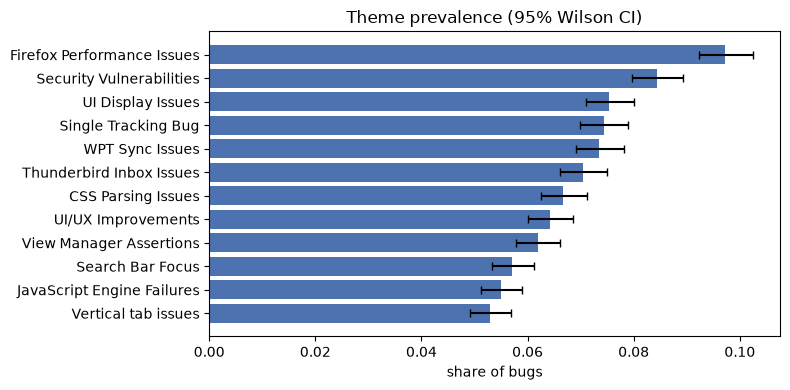

In [90]:
from statsmodels.stats.proportion import proportion_confint

s = bugs["cluster_theme"].dropna()
N = len(s)
print(f"主题占比（N={N:,}，95% Wilson CI）:")
rows = []
for theme, c in s.value_counts().head(12).items():
    lo, hi = proportion_confint(c, N, alpha=0.05, method="wilson")
    rows.append((theme, c, c / N, lo, hi))
    print(f"  {theme[:34]:<34} {c/N:6.2%}  [{lo:.2%}, {hi:.2%}]  (n={c})")

labs = [r[0][:26] for r in rows]; share = [r[2] for r in rows]
err = [[r[2]-r[3] for r in rows], [r[4]-r[2] for r in rows]]
plt.figure(figsize=(8, 4)); plt.barh(labs, share, xerr=err, color="#4c72b0", capsize=3)
plt.gca().invert_yaxis(); plt.xlabel("share of bugs"); plt.title("Theme prevalence (95% Wilson CI)"); plt.tight_layout(); plt.show()

## Step 5 ⭐ · 抽取 agent（LangGraph 多智能体 supervisor + 真实工具调用 + MCP 接地）

对每个 bug 抽 `{area, severity, kind}`。核心不是写死顺序的流水线，而是一个 **supervisor 路由 + 内层 ReAct 工具循环** 的多智能体图——**每一步下一个节点由 LLM 在运行时决定**，不同 bug 走出不同轨迹。

```
                         START
                           │
                           ▼
              ┌──────► supervisor ──FINISH──► END
              │       （唯一大脑：每轮决定下一步叫谁）
              │            │ research / extract / critique / FINISH
              │   ┌────────┼───────────┐
              │   ▼        ▼           ▼
              │ researcher extractor  critic
              │ (工具循环)  (出 JSON)  (schema+忠实度)
              │   │ ▲        │          │
              │   ▼ │(内层)   │          │
              │  tools       │          │
              └───┴──────────┴──────────┘
                （三个专家干完活都回 supervisor）
```

- **supervisor**（LLM 路由）：看当前状态（证据多少、有无草稿、critic 说了啥、步数）输出一个决策 `{next, reason}`。这是图里**唯一的分叉点**——是否检索、是否重抽、何时收工，全在这里动态决定。
- **researcher**（内层 ReAct 循环）：`bind_tools` 让 LLM 自己发 `tool_calls`，多跳收集证据，够了就收工。三个**互不替代**的工具：`search_similar_bugs`（Chroma 向量库找先例）、`read_bug`（读某条近邻全文，多跳）、`component_prior`（官方组件的历史统计画像）。
- **extractor**（不碰工具）：仅凭 bug 文本 + 已收集证据（+ 上次拒绝理由）输出 `{area, severity, kind}` JSON。
- **critic**（只审不改）：先跑**免费 schema 检查**（字段齐、枚举合法），通过再花一次 LLM-judge 查忠实度；给出 `ok` 和拒绝理由，但**打回后去哪由 supervisor 决定**。

**为什么是 agent 而不是 workflow**：没有一条写死的业务顺序边——文本自明的 bug 会跳过检索直达 extract；被 critic 打回时，supervisor 读拒绝理由判断「只是格式错 → 重抽」还是「area 跑偏 → 补检索」。**同一失败入口走出不同恢复路线**，这是固定流水线给不了的。轨迹日志（`decisions`）汇总成分布图，就是 agent 能力的直接证据。

**两级安全阀 + 图外后处理**：`MAX_STEPS`（supervisor 决策预算）+ LangGraph `recursion_limit`（框架级防死循环）；`area → area_component` 归一化和 `duplicates` 标注是**确定性收尾，放图外**，不占 agent 节点。

**MCP 接地是真实调用**：字段 catalog（定义 + 枚举）由 `mcp_server.py`（stdio MCP server）提供，notebook 启动时作为 MCP client 拉取一次注入 extractor/critic 的 prompt——schema 单一事实源。

In [91]:
# —— MCP 接地（真实调用）——
# 字段 catalog 与 component taxonomy 由 mcp_server.py（stdio MCP server）提供，
# 这个 cell 是 MCP client：拉取 catalog -> 生成 SCHEMA / 枚举 / taxonomy，全程单一事实源。
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

async def mcp_call(tool, args=None):
    params = StdioServerParameters(command=sys.executable, args=["mcp_server.py"])
    async with stdio_client(params) as (read, write):
        async with ClientSession(read, write) as sess:
            await sess.initialize()
            res = await sess.call_tool(tool, args or {})
            return res.content[0].text

CATALOG = json.loads(await mcp_call("get_field_catalog"))        # ipykernel 支持顶层 await
COMPONENTS = json.loads(await mcp_call("get_component_taxonomy"))

SCHEMA = "; ".join(f"{k}: {v}" for k, v in CATALOG["fields"].items()) + \
         "; enums: " + json.dumps(CATALOG["enums"])
VALID_SEV, VALID_KIND = set(CATALOG["enums"]["severity"]), set(CATALOG["enums"]["kind"])
print(f"MCP catalog loaded: {list(CATALOG['fields'])} | taxonomy: {len(COMPONENTS)} components")

# —— 四类角色各一段 prompt（schema 全部来自 MCP catalog，单一事实源）——

# supervisor：唯一大脑，每轮只输出一个路由决策（这是图里真正的“agent 决策”）
SUPERVISOR_PROMPT = (
    'You are the SUPERVISOR of a bug-field extraction team. Route to exactly ONE worker per turn.\n'
    'Workers:\n'
    '- research: gather evidence via retrieval tools (similar bugs / read a bug / component stats). '
    'Use when the affected area is unclear or you need precedents.\n'
    '- extract: write the JSON {{area,severity,kind}} from bug text + evidence. '
    'Use when you have enough info, OR to REWRITE after a critic rejection.\n'
    '- critique: check the current extraction (schema + faithfulness). Use right after a new extraction.\n'
    '- FINISH: stop. Use ONLY after the critic accepted it (critic_ok=true), or to give up near the step budget.\n'
    'Be efficient: if the bug text is self-explanatory, SKIP research and go straight to extract '
    '(wasting retrieval calls is penalized). After a rejection, decide smartly — if the critique is a '
    'format/enum error go extract (rewrite); if it is a wrong-area / weak-grounding problem go research first.\n'
    'Reply ONLY JSON: {{"next": "research|extract|critique|FINISH", "reason": str}}.\n'
    'Team state:\n{state}')

# researcher：内层 ReAct，system prompt 描述可用工具，由 LLM 自主决定调用序列
RESEARCH_SYS = (
    'You are the RESEARCHER. Collect JUST ENOUGH evidence to classify a bug into these fields: {schema}\n'
    'Tools you may call (multi-step is fine; stop early once you have enough):\n'
    '- search_similar_bugs(bug_id): historical bugs most similar to this one (id, similarity, official component, short summary).\n'
    '- read_bug(bug_id): full text of ONE bug — use to disambiguate a promising but unclear neighbor.\n'
    '- component_prior(component): historical stats for an official component: bug count, and the severity distribution + typical severity already mapped to the low/med/high scale (untriaged bugs excluded), plus example summaries. Use it to sanity-check your severity against the component norm.\n'
    'A good chain is often search -> (read the best neighbor) -> (component_prior once area is likely). '
    'When done, reply with a SHORT plain-text evidence summary (NO JSON, NO tool call).').format(schema=SCHEMA)

# extractor：不使用工具，仅凭文本 + 证据（+ 上次拒绝理由）出 JSON
EXTRACT_PROMPT = (
    'Extract structured fields from a software bug report. Field semantics (data catalog): {schema}\n'
    'Use the bug text and the collected evidence (ground your answer, do NOT copy neighbors blindly). '
    'Return ONLY a JSON object '
    '{{"area": str, "severity": "low|med|high", "kind": "crash|ui|performance|security|data|other"}}.\n'
    '{feedback}'
    'Bug report:\n```{text}```\nCollected evidence:\n{evidence}')

# critic：只审不改
CRITIQUE_PROMPT = ('You are a reviewer. Is this extraction faithful to the bug report and well-formed? '
    'Reject (ok=false) ONLY for a clear contradiction, invented facts, or an off-topic area.\n'
    'Reply ONLY JSON: {{"ok": true|false, "reason": str}}.\n'
    'Bug report:\n```{text}```\nExtraction: {extraction}')

def schema_ok(obj):
    if not isinstance(obj, dict): return False, "output is not a JSON object"
    if not isinstance(obj.get("area"), str) or not obj["area"].strip(): return False, "missing 'area'"
    if obj.get("severity") not in VALID_SEV: return False, "bad 'severity'"
    if obj.get("kind") not in VALID_KIND: return False, "bad 'kind'"
    return True, ""

MCP catalog loaded: ['area', 'severity', 'kind'] | taxonomy: 281 components


In [92]:
# —— researcher 的三个工具：@tool 暴露给 LLM bind_tools，由模型在内层 ReAct 循环里自主调用 ——
# 三者互不替代：search=广撒网找先例 / read=深挖一条全文 / prior=查组件历史画像。
# 底层全是确定性查表 / 查向量库，零 LLM 成本；@tool 只暴露 name/描述/参数 schema 给 LLM。
import difflib
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

_by_id = bugs.assign(_sid=bugs["id"].astype(str)).set_index("_sid")

def _similar_bugs(bug_id, k=6):
    """查 Step 2 的 ChromaDB 向量库，返回该 bug 的 top-k 近邻（复用已缓存向量，零 API 成本）。"""
    got = col.get(ids=[str(bug_id)], include=["embeddings"])["embeddings"]
    if not len(got):                                           # 该 id 不在库中（安全兜底）
        return []
    v = np.asarray(got[0]).tolist()
    res = col.query(query_embeddings=[v], n_results=k + 1)     # +1：自己会排第一
    out = []
    for i, dist in zip(res["ids"][0], res["distances"][0]):
        if i == str(bug_id) or i not in _by_id.index:         # 跳过自己
            continue
        r = _by_id.loc[i]
        out.append({"id": i, "sim": round(1.0 - dist, 3),
                    "component": str(r["component"]), "summary": str(r["summary"])[:120]})
    return out[:k]

def _nearest_component(area):
    """把自由文本 area 归一化到 MCP taxonomy 里最接近的官方 component（difflib，纯字符串匹配，无 LLM）。"""
    m = difflib.get_close_matches(str(area), COMPONENTS, n=1, cutoff=0.0)
    return m[0] if m else None

def _read_bug(bug_id):
    """读某条 bug 的完整原文（component + summary + 截断的 description）。"""
    if str(bug_id) not in _by_id.index:
        return {"error": f"bug {bug_id} not found"}
    r = _by_id.loc[str(bug_id)]
    return {"id": str(bug_id), "component": str(r["component"]), "summary": str(r["summary"]),
            "description": str(r.get("description", ""))[:1200]}

# Bugzilla 官方档位 S1-S4 / 旧标签 -> 抽取枚举 low|med|high；"--"/N/A/空 视为未分诊，不计入分布。
# 依据 Mozilla 官方定义：S1/S2=灾难/严重→high，S3/normal=一般→med，S4/minor/trivial=轻微→low。
_SEV_MAP = {"s1": "high", "s2": "high", "critical": "high", "blocker": "high", "major": "high",
            "s3": "med", "normal": "med",
            "s4": "low", "minor": "low", "trivial": "low"}

def _map_severity(raw):
    """把原始 severity 值映射到抽取枚举；未分诊(-- / N/A / 空)或未知值返回 None。"""
    return _SEV_MAP.get(str(raw).strip().lower())

def _component_prior(component):
    """给一个（可能不精确的）组件名，回官方组件的历史画像：bug 数、已分诊数、
    severity 分布（映射到 low/med/high 且剔除未分诊）、典型 severity、示例标题。"""
    near = _nearest_component(component) or str(component)     # 先归一化到官方名
    sub = bugs[bugs["component"].astype(str) == near]
    mapped = sub["severity"].map(_map_severity).dropna()       # 只保留已分诊(S1-S4/旧标签)
    dist = mapped.value_counts(normalize=True).round(2).to_dict()
    typical = mapped.mode().iloc[0] if not mapped.empty else None   # 众数=典型 severity
    return {"component": near, "n_bugs": int(len(sub)), "n_triaged": int(len(mapped)),
            "severity_dist": dist, "typical_severity": typical,
            "example_summaries": sub["summary"].astype(str).head(3).tolist()}

@tool
def search_similar_bugs(bug_id: str) -> str:
    """Return up to 6 historical bugs most similar to the given bug id (semantic vector search
    over cached embeddings): id, similarity, official component, short summary. First step to
    ground the classification in real precedents."""
    return json.dumps(_similar_bugs(bug_id, k=6))

@tool
def read_bug(bug_id: str) -> str:
    """Return the FULL text (component, summary, description) of one bug. Use it to deep-dive a
    promising but unclear neighbor returned by search_similar_bugs."""
    return json.dumps(_read_bug(bug_id))

@tool
def component_prior(component: str) -> str:
    """Return historical stats for an official component: total bug count, how many were triaged,
    the severity distribution mapped to the extraction enum (low/med/high; untriaged '--'/N/A
    excluded), the typical (modal) severity, and example summaries. Use it once the area is likely,
    to calibrate severity/kind against the component's norm."""
    return json.dumps(_component_prior(component))

RESEARCH_TOOLS = [search_similar_bugs, read_bug, component_prior]
TOOLS_BY_NAME = {t.name: t for t in RESEARCH_TOOLS}
research_llm = ChatOpenAI(model=CHAT_MODEL, temperature=0).bind_tools(RESEARCH_TOOLS)  # researcher 内层 LLM

_demo = str(pairs.iloc[0]["dup_id"])
print("tool check · search_similar_bugs:", [(d["id"], d["sim"]) for d in _similar_bugs(_demo, k=3)])
print("tool check · read_bug ->", _read_bug(_demo)["component"])
print("tool check · component_prior('webrender graphics') ->",
      {k: json.loads(component_prior.invoke({"component": "webrender graphics"}))[k]
       for k in ("component", "n_bugs", "n_triaged", "typical_severity", "severity_dist")})

tool check · search_similar_bugs: [('2052389', 1.0), ('1947739', 0.848), ('1984946', 0.8)]
tool check · read_bug -> Sidebar
tool check · component_prior('webrender graphics') -> {'component': 'Graphics', 'n_bugs': 141, 'n_triaged': 45, 'typical_severity': 'med', 'severity_dist': {'med': 0.58, 'high': 0.27, 'low': 0.16}}


In [93]:
import re
from operator import add
from typing import TypedDict, Annotated
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END

DUP_SIM = 0.75            # 近邻相似度超过它才 flag 为潜在重复（启发式，精确度由 Step 7 量化）
MAX_STEPS = 10            # 安全阀①：supervisor 最多决策次数（业务级预算）
RESEARCH_MAX_CALLS = 4    # researcher 内层 ReAct 每次最多调几轮工具

class S(TypedDict):
    bug_id: str
    text: str
    evidence: Annotated[list, add]     # researcher 追加：工具结果 + 证据小结
    extraction: dict | None            # extractor 写入的草稿
    ok: bool                           # critic 判定
    critique: str                      # critic 的拒绝理由（供 supervisor / extractor 参考）
    decisions: Annotated[list, add]    # supervisor 每轮决策 -> 轨迹日志
    steps: int                         # supervisor 已决策步数
    n_extract: int                     # extractor 运行次数（区分 first-pass / 重抽）

def _parse_json(txt):
    try: return json.loads(txt)
    except Exception:
        m = re.search(r"\{.*\}", txt or "", re.S)              # 容错：从自由文本里抠出 JSON
        try: return json.loads(m.group()) if m else None
        except Exception: return None

def _fmt_ev(e):
    if "tool" in e:   return f"[{e['tool']}({e.get('args', {})})] -> {e['result']}"
    if "note" in e:   return f"[researcher note] {e['note']}"
    return str(e)

# ---- supervisor：唯一大脑，每轮输出一个路由决策（真正的 agent 决策点）----
def _sup_state(s):
    ev = s["evidence"]
    return json.dumps({
        "bug_text": str(s["text"])[:600],
        "evidence_count": len(ev),
        "evidence_digest": [e.get("tool") or "note" for e in ev][-6:],
        "has_extraction": s["extraction"] is not None,
        "current_extraction": s["extraction"],
        "critic_ok": s["ok"],
        "last_critique": s["critique"],
        "steps_used": s["steps"], "max_steps": MAX_STEPS,
    }, ensure_ascii=False)

def n_supervisor(s):
    allowed = {"research", "extract", "critique", "FINISH"}
    if s["steps"] >= MAX_STEPS:                                 # 安全阀①：预算用尽，强制收工
        dec = {"next": "FINISH", "reason": "step budget exhausted"}
    else:
        raw = call_llm(SUPERVISOR_PROMPT.format(state=_sup_state(s)), json_mode=True)
        try: d = json.loads(raw)
        except Exception: d = {}
        nxt = d.get("next")
        if nxt not in allowed:                                  # 非法输出兜底
            nxt = "extract" if s["extraction"] is None else "critique"
        if nxt in ("critique", "FINISH") and s["extraction"] is None:
            nxt = "extract"                                     # 没草稿就不能审 / 不能空手收工
        dec = {"next": nxt, "reason": str(d.get("reason", ""))[:200]}
    return {"decisions": [dec], "steps": s["steps"] + 1}

# ---- researcher：内层 ReAct 循环，LLM 自主决定调哪个工具、调几次 ----
def n_researcher(s):
    last_reason = s["decisions"][-1].get("reason", "") if s["decisions"] else ""
    prior = "\n".join(_fmt_ev(e) for e in s["evidence"]) or "(none yet)"   # 已查过什么，避免二次 research 重复取数
    hist = [SystemMessage(RESEARCH_SYS),
            HumanMessage(f"Bug id: {s['bug_id']}\nBug report:\n```{str(s['text'])[:1500]}```\n"
                         f"Why you were called: {last_reason}\n"
                         f"Evidence already collected (do NOT repeat these same tool calls):\n{prior[:1200]}")]
    collected = []
    for _ in range(RESEARCH_MAX_CALLS):
        for _attempt in range(6):
            try:
                resp = research_llm.invoke(hist); break
            except Exception as _e:
                if getattr(_e, 'status_code', None) == 429 or 'rate_limit' in str(_e).lower():
                    _w = 2 ** _attempt * 5
                    print(f'  [rate limit/researcher] waiting {_w}s ...')
                    time.sleep(_w)
                else:
                    raise
        hist.append(resp)
        if not resp.tool_calls:                                # 不再调工具 = 收工，content 作证据小结
            if resp.content: collected.append({"note": str(resp.content)[:400]})
            break
        for tc in resp.tool_calls:                             # 执行 LLM 发起的真实 tool_calls
            try: out = TOOLS_BY_NAME[tc["name"]].invoke(tc["args"])
            except Exception as e: out = json.dumps({"error": str(e)})
            hist.append(ToolMessage(str(out), tool_call_id=tc["id"]))
            collected.append({"tool": tc["name"], "args": tc["args"], "result": str(out)[:400]})
    return {"evidence": collected}

# ---- extractor：不碰工具，仅凭文本 + 证据（+ 上次拒绝理由）出 JSON ----
def n_extractor(s):
    ev = "\n".join(_fmt_ev(e) for e in s["evidence"]) or "(no evidence gathered)"
    fb = f"A reviewer previously rejected an extraction: {s['critique']}. Fix it.\n" if s["critique"] else ""
    raw = call_llm(EXTRACT_PROMPT.format(schema=SCHEMA, feedback=fb,
                                         text=str(s["text"])[:2000], evidence=ev[:1500]), json_mode=True)
    return {"extraction": _parse_json(raw), "n_extract": s["n_extract"] + 1, "critique": ""}

# ---- critic：只审不改（schema 免费检查 + 一次 LLM-judge 忠实度）----
def n_critic(s):
    ok, why = schema_ok(s["extraction"])
    if not ok:
        return {"ok": False, "critique": why}
    raw = call_llm(CRITIQUE_PROMPT.format(text=str(s["text"])[:2000],
                                          extraction=json.dumps(s["extraction"])), json_mode=True)
    try: v = json.loads(raw)
    except Exception: v = {}
    return {"ok": bool(v.get("ok", True)), "critique": v.get("reason", "")}

def route_supervisor(s):
    """图里唯一分叉点：完全由 supervisor 本轮决策决定去哪。"""
    return s["decisions"][-1]["next"]

g = StateGraph(S)
g.add_node("supervisor", n_supervisor)
g.add_node("researcher", n_researcher)
g.add_node("extractor", n_extractor)
g.add_node("critic", n_critic)
g.add_edge(START, "supervisor")
g.add_conditional_edges("supervisor", route_supervisor,       # 动态路由（非写死顺序）
                        {"research": "researcher", "extract": "extractor",
                         "critique": "critic", "FINISH": END})
g.add_edge("researcher", "supervisor")                        # 专家干完活一律回 supervisor -> 外层循环
g.add_edge("extractor", "supervisor")
g.add_edge("critic", "supervisor")
app = g.compile()
print("supervisor agent compiled:", " / ".join(app.get_graph().nodes))

supervisor agent compiled: __start__ / supervisor / researcher / extractor / critic / __end__


In [94]:
# 抽取样本：只从「有像样 description」的 bug 里抽，保证抽取和后面人工标注都有足够信息
pool = bugs[bugs["desc_words"] >= 40].sample(min(EXTRACT_N, (bugs.desc_words>=40).sum()), random_state=SEED).reset_index(drop=True)
recs, oks, steps_list, n_extracts, trajs, dup_flags = [], [], [], [], [], []
for i, (bid, t) in enumerate(zip(pool["id"].astype(str), pool["text"]), 1):
    init = {"bug_id": bid, "text": t, "evidence": [], "extraction": None, "ok": False,
            "critique": "", "decisions": [], "steps": 0, "n_extract": 0}
    fin = app.invoke(init, {"recursion_limit": 60})            # 安全阀②：框架级防死循环

    # —— 图外确定性后处理（不占 agent 节点）——
    ext = dict(fin.get("extraction") or {})
    ext["area_component"] = _nearest_component(ext["area"]) if ext.get("area") else None   # difflib 归一化
    nbrs = _similar_bugs(bid, k=6)                                                          # 查向量库标 duplicates
    dup_flags.append([d for d in nbrs if d["sim"] >= DUP_SIM][:5])

    recs.append(ext); oks.append(bool(fin["ok"])); steps_list.append(fin["steps"])
    n_extracts.append(fin["n_extract"]); trajs.append([d["next"] for d in fin["decisions"]])
    if i % 15 == 0 or i == len(pool): print(f"  processed {i}/{len(pool)}")
    time.sleep(2)   # 每条 bug 处理完后短暂等待，避免连续调用触发 TPM 限速

n = len(recs)
after_retry = sum(oks) / n                                            # 最终 valid yield
first_pass  = sum(1 for o, e in zip(oks, n_extracts) if o and e == 1) / n   # 一次抽取即过 critic
mean_steps  = sum(steps_list) / n
zero_research_pct = sum(1 for tr in trajs if "research" not in tr) / n
print(f"valid yield: first-pass {first_pass:.1%} -> after critique-retry {after_retry:.1%} "
      f"(agent self-correction {after_retry-first_pass:+.1%})")
print(f"agent trajectories: mean {mean_steps:.1f} supervisor steps | "
      f"{zero_research_pct:.0%} solved with ZERO retrieval (agent skipped tools)")
print(f"dedup flagged {sum(1 for d in dup_flags if d)}/{n} bugs with possible duplicates (sim >= {DUP_SIM})")

extract_df = pool.copy()
extract_df["llm_area"]      = [r.get("area") for r in recs]
extract_df["llm_severity"]  = [r.get("severity") for r in recs]
extract_df["llm_kind"]      = [r.get("kind") for r in recs]
extract_df["llm_area_comp"] = [r.get("area_component") for r in recs]     # taxonomy 归一化结果
extract_df["llm_dup_ids"]   = [",".join(d["id"] for d in ds) for ds in dup_flags]
extract_df["_ok"]           = oks
extract_df["_steps"]        = steps_list
extract_df["_traj"]         = [" → ".join(tr) for tr in trajs]            # 每条 bug 的 supervisor 轨迹
extract_df[["id", "component", "llm_area", "llm_area_comp", "llm_severity", "llm_kind",
            "llm_dup_ids", "_steps", "_ok", "_traj"]].head()

  processed 15/50
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit/researcher] waiting 5s ...
  [rate limit/researcher] waiting 5s ...
  processed 30/50
  [rate limit/researcher] waiting 5s ...
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit/researcher] waiting 5s ...
  [rate limit/researcher] waiting 5s ...
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit/researcher] waiting 5s ...
  [rate limit/researcher] waiting 5s ...
  [rate limit/researcher] waiting 5s ...
  [rate limit/researcher] waiting 5s ...
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit/researcher] waiting 5s ...
  [rate limit/researcher] waiting 5s ...
  processed 45/50
  [rate limit] waiting 5s before retry 1/6 ...
  [rate limit/researcher] waiting 5s ...
  [rate limit/researcher] waiti

,id,component,llm_area,llm_area_comp,llm_severity,llm_kind,llm_dup_ids,_steps,_ok,_traj
0,764076,Layout: Scrolling and Overflow,Layout,Layout,med,ui,2027840,3,True,extract → critique → FINISH
1,354493,Networking,networking,Networking,high,security,,3,True,extract → critique → FINISH
2,2022394,Storage: localStorage & sessionStorage,Storage,Storage,high,security,,3,True,extract → critique → FINISH
3,1983429,Mail Window Front End,Mail Window Front End,Mail Window Front End,high,ui,"2039936,1944442",3,True,extract → critique → FINISH
4,1918296,OS Integration,OS Integration,OS Integration,low,ui,1977643,3,True,extract → critique → FINISH


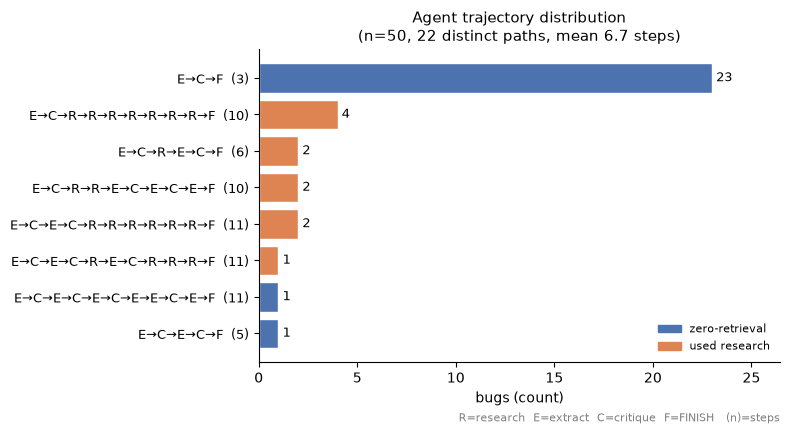

distinct trajectories: 22 | zero-retrieval: 50% | mean steps: 6.7
valid yield: first-pass 46% -> after critique-retry 58%


In [95]:
# Agent 能力的直接证据：同一张图、不同输入走出不同轨迹（若是写死 workflow 只会有一条）
from collections import Counter
sig = Counter(" → ".join(tr) for tr in trajs)
top = sig.most_common(8)

# 轨迹用首字母缩写，避免超长 y 轴标签把 bar 挤没；步数标在括号里
_abbr = {"research": "R", "extract": "E", "critique": "C", "FINISH": "F"}
def _short(path):
    steps = path.split(" → ")
    return f"{'→'.join(_abbr.get(s, s[0].upper()) for s in steps)}  ({len(steps)})"

top = top[::-1]                                                   # 倒序：最多的排最上面
traj_labels = [_short(k) for k, _ in top]
traj_vals   = [v for _, v in top]
bar_colors  = ["#dd8452" if "research" in k else "#4c72b0" for k, _ in top]  # 橙=用了检索, 蓝=zero-retrieval

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(traj_labels, traj_vals, color=bar_colors, edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)                        # 数字紧贴 bar 末端
ax.set_xlim(0, max(traj_vals) * 1.15)                            # 给标签留白
ax.set_xlabel("bugs (count)")
ax.set_title(f"Agent trajectory distribution\n(n={n}, {len(sig)} distinct paths, mean {mean_steps:.1f} steps)", fontsize=11)
ax.tick_params(axis="y", labelsize=9)
for side in ("top", "right"): ax.spines[side].set_visible(False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#4c72b0", label="zero-retrieval"),
                   Patch(color="#dd8452", label="used research")],
          fontsize=8, loc="lower right", frameon=False)
ax.text(1.0, -0.16, "R=research  E=extract  C=critique  F=FINISH   (n)=steps",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color="gray")
plt.tight_layout(); plt.show()
print(f"distinct trajectories: {len(sig)} | zero-retrieval: {zero_research_pct:.0%} | mean steps: {mean_steps:.1f}")
print("valid yield: first-pass {:.0%} -> after critique-retry {:.0%}".format(first_pass, after_retry))

### Step 5 补充 · 用抽取/结构化字段**刻画每个簇**（可解释性）

聚类只说了"哪些 bug 抱团"，簇本身是匿名的。这里把字段接回来给每簇画像：
- **component**（全库都有，是 `llm_area` 的全库代理）→ 主导子系统，稳健；
- **llm_kind**（Step 5 抽取，仅样本覆盖）→ 叠加缺陷类型色彩，作抽样示意。

于是 *embedding 的簇 + LLM 起的名 + 结构化字段* 三者互相印证，簇不再是黑盒。

In [96]:
# 每簇画像：全库 component 主导 + 抽取样本的 llm_kind 叠加（仅示意）
_row_cluster = {id_: labels[r] for r, id_ in enumerate(ids)}
_kbc = (extract_df.assign(cluster=extract_df["id"].astype(str).map(_row_cluster))
        .groupby("cluster")["llm_kind"]
        .agg(lambda s: s.dropna().mode().iloc[0] if s.dropna().size else "-"))
prof = []
for c in range(best_k):
    m = labels == c
    top_comp = bugs.loc[m, "component"].value_counts().head(2)
    prof.append({"cluster": c, "theme": names.get(c, f"cluster {c}"),
                 "n": int(m.sum()),
                 "top_components": ", ".join(f"{k}({v})" for k, v in top_comp.items()),
                 "llm_kind*": _kbc.get(c, "-")})
prof_df = pd.DataFrame(prof).sort_values("n", ascending=False).reset_index(drop=True)
print("簇画像（llm_kind* 来自 Step5 的 50 条抽取样本，覆盖有限，仅作示意）：")
prof_df

簇画像（llm_kind* 来自 Step5 的 50 条抽取样本，覆盖有限，仅作示意）：


,cluster,theme,n,top_components,llm_kind*
0,3,Firefox Performance Issues,1266,"Audio/Video: Playback(103), Untriaged(99)",performance
1,9,Security Vulnerabilities,1098,"Networking(72), DOM: Content Processes(72)",security
2,16,UI Display Issues,981,"Widget: Gtk(162), Widget: Win32(90)",ui
3,4,Single Tracking Bug,968,"DOM: Core & HTML(47), General(46)",data
4,12,WPT Sync Issues,957,"DOM: Core & HTML(223), CSS Parsing and Computation(152)",other
5,13,Thunderbird Inbox Issues,917,"Untriaged(235), Folder and Message Lists(110)",ui
6,14,CSS Parsing Issues,869,"CSS Parsing and Computation(262), DOM: Core & HTML(78)",other
7,10,UI/UX Improvements,835,"Messaging System(90), Settings UI(84)",ui
8,8,View Manager Assertions,806,"JavaScript Engine(69), Widget: Gtk(42)",crash
9,2,Search Bar Focus,743,"Address Bar(167), Settings UI(62)",ui


## Step 6 ⭐ · Auto-rater（LLM-as-judge）+ Cohen's κ 校准

用一个 LLM 当"自动评分器"给抽取打分，但**不能假设它可信 —— 必须用人工标注证明**。
做法：抽一批样本写成**人工可读**的 `human_labels.csv`（分列：component / summary / description / LLM 抽的字段），
你按标注说明填 `human_good`（1=忠实合理 / 0=明显错误），再算 **LLM-judge vs 人工的 Cohen's κ**。

> κ 是本项目"评估可信度"的关键证据。下面这段：若 `human_labels.csv` 尚未标注 → 生成模板 + 标注指南；标注后重跑本 cell → 算出 κ。

In [97]:
HUMAN = "human_labels.csv"
GUIDE = "human_labels_GUIDE.md"

ANNOTATION_GUIDE = """# 标注指南 · human_labels.csv

你要判断的是：**LLM 抽取的 3 个字段，是否忠实、合理地反映了这条 bug 的文本内容。**
（不是判断这个 bug 本身重不重要、该不该修 —— 只看"抽得对不对"。你不需要是 Firefox 工程师。）

每行看 4 列原文（component / summary / description）和 3 列 LLM 输出（llm_area / llm_severity / llm_kind），
在 `human_good` 里填：

- `1`（好）：area 和文本主题一致；severity/kind 与文本语气不矛盾
    （例：文本提到 crash / use-after-free / security → kind=security 或 crash、severity=high 合理）
- `0`（差）：area 明显跑偏（文本讲 PDF，却标成 Networking）；或 kind/severity 明显相反
    （例：只是个小 UI 改动，却标成 kind=crash、severity=high）
- 留空：文本太短/太专业，你实在判不了 —— **跳过即可，不影响 κ 计算**（只用标了的行）

字段含义：
- llm_area：受影响的子系统/主题（短语）
- llm_severity：low | med | high
- llm_kind：crash | ui | performance | security | data | other

标 20~40 行即可算出稳定的 Cohen's κ。标完保存，回到 notebook 重跑 Step 6。
"""

JUDGE_MODEL = "gpt-4o"          # judge 专用模型（与 agent 的 CHAT_MODEL 分离）
JUDGE_THRESHOLD = 5             # >=5 才算 good，对齐 gpt-4o 打分习惯
# 这 4 条用作 few-shot 锚点，不参与 κ 计算
JUDGE_FEW_SHOT_IDS = {1963368, 1991810, 2041211, 2048096}

# Few-shot 校准例子（从人工标注里挑的，覆盖明确好/明确差/边界）
JUDGE_FEW_SHOT = """\
Calibration examples (do NOT score these, use them to calibrate your scale):

[Example A — score 5] Bug: [Graphics: WebRender] Hit MOZ_CRASH(bug: texture not allocated) — crash during fuzzing.
Extraction: {"area": "WebRender", "severity": "high", "kind": "crash"}
→ area matches component exactly; crash + high severity directly stated in text. Score: 5

[Example B — score 1] Bug: [Untriaged] gmail doesn't load in Nightly — performance issue reported on Gmail.
Extraction: {"area": "gmail", "severity": "high", "kind": "performance"}
→ area is a website name, not a browser component; completely wrong category. Score: 1

[Example C — score 2] Bug: [Upstream Synchronization] Port CSP baseline enforcement — internal security policy change.
Extraction: {"area": "security", "severity": "high", "kind": "crash"}
→ area acceptable but kind=crash is wrong (no crash; it's a policy/security change). Score: 2

[Example D — score 4] Bug: [Gecko Profiler] Lock-order-inversion (potential deadlock) in ProfilerParent.
Extraction: {"area": "Gecko Profiler", "severity": "high", "kind": "performance"}
→ area correct; severity high reasonable for deadlock risk; kind=performance acceptable though "other" also fits. Score: 4
"""

def judge_good(text, extraction, threshold=JUDGE_THRESHOLD):
    """judge 给 1-5 分；>=threshold 记为'好'(1)，否则 0。使用 few-shot 校准打分尺度。temperature=0 保证可复现。"""
    p = ('Rate whether the extracted JSON is a FAITHFUL and REASONABLE summary of the bug, score 1-5.\n'
         'ONLY judge whether area/severity/kind are defensible given the text; do NOT penalize for '
         'missing minor details or incompleteness.\n'
         '5=perfectly faithful; 4=faithful with minor issues; 3=acceptable; 2=area or kind clearly off; 1=completely wrong.\n\n'
         + JUDGE_FEW_SHOT +
         '\n--- Now score THIS bug (reply ONLY JSON: {"score": 1-5, "reason": str}) ---\n'
         f'Bug:\n```{str(text)[:2000]}```\nExtraction: {extraction}')
    try:
        r = oai.chat.completions.create(model=JUDGE_MODEL, temperature=0, max_tokens=300,
                                        response_format={"type": "json_object"},
                                        messages=[{"role": "user", "content": p}]).choices[0].message.content
        return int(int(json.loads(r).get("score", 0)) >= threshold)
    except Exception:
        return 0

need_template = (not os.path.exists(HUMAN)) or ("human_good" not in pd.read_csv(HUMAN).columns) \
                or pd.read_csv(HUMAN)["human_good"].dropna().astype(str).str.strip().replace("", np.nan).dropna().empty

if need_template:
    tmpl = extract_df[extract_df["_ok"]].copy()
    tmpl = tmpl[["id", "component", "summary", "description", "llm_area", "llm_severity", "llm_kind"]]
    tmpl["description"] = tmpl["description"].astype(str).str.slice(0, 1200)   # 截断，标注够用即可
    tmpl["human_good"] = ""                                                     # 待你填 1 / 0 / 留空跳过
    tmpl.to_csv(HUMAN, index=False)
    with open(GUIDE, "w") as f:
        f.write(ANNOTATION_GUIDE)
    kappa = None
    print(f"已生成待标注模板 {HUMAN}（{len(tmpl)} 行）和标注指南 {GUIDE}。")
    print("请打开 CSV，按指南给每行 human_good 填 1/0（看不懂可留空跳过），保存后重跑本 cell 计算 κ。")
else:
    from sklearn.metrics import cohen_kappa_score, confusion_matrix
    from collections import Counter as _Counter
    h = pd.read_csv(HUMAN)
    h = h[h["human_good"].astype(str).str.strip().isin(["0", "1"])].copy()
    h["human_good"] = h["human_good"].astype(int)
    h["_ext"] = h.apply(lambda r: json.dumps({"area": r["llm_area"], "severity": r["llm_severity"], "kind": r["llm_kind"]}), axis=1)
    h["_text"] = "[" + h["component"].astype(str) + "] " + h["summary"].astype(str) + "\n" + h["description"].astype(str)
    # few-shot 行只用来造 prompt，不参与 κ
    h_kappa = h[~h["id"].isin(JUDGE_FEW_SHOT_IDS)].copy().reset_index(drop=True)
    judge = [judge_good(t, e) for t, e in zip(h_kappa["_text"], h_kappa["_ext"])]
    kappa = float(cohen_kappa_score(h_kappa["human_good"], judge))
    print(f"labeled rows: {len(h)} total, {len(h_kappa)} used for κ ({len(JUDGE_FEW_SHOT_IDS)} held out as few-shot anchors)")
    print(f"judge model: {JUDGE_MODEL} | threshold: {JUDGE_THRESHOLD}")
    print(f"Cohen's κ (judge vs human) = {kappa:.3f}")
    print("confusion (rows=human, cols=judge):\n", confusion_matrix(h_kappa["human_good"], judge))
    # 1-5 score distribution（需要重取原始分，这里只有 0/1 结果，打印 good 比例）
    print(f"judge good={sum(judge)}/{len(judge)} ({sum(judge)/len(judge):.0%}) | human good={h_kappa['human_good'].sum()}/{len(h_kappa)} ({h_kappa['human_good'].mean():.0%})")

labeled rows: 50 total, 46 used for κ (4 held out as few-shot anchors)
judge model: gpt-4o | threshold: 5
Cohen's κ (judge vs human) = 0.556
confusion (rows=human, cols=judge):
 [[ 4  1]
 [ 4 37]]
judge good=38/46 (83%) | human good=41/46 (89%)


## Step 7 ⭐ · 去重检索评估（硬标签 hit@k + MRR）

**这是 headline。** 对每一条已知的"重复 bug"，用它的向量在全库检索最相似的 bug，看它真正的"主 bug"有没有排进 top-k。
因为有 `dupe_of` 硬标签，这是**真·检索指标**，不是模型自说自话：
- **hit@k**（命中率 / success rate）：重复 bug 的主 bug 落在前 k 的比例（每条只有 1 个正确答案）；
- **MRR**：主 bug 排名倒数的平均，衡量整体排序质量。

向量已归一化，`cosine 相似度 == 点积`，全库检索用一次矩阵乘法即可。

In [98]:
id_to_row = {id_: r for r, id_ in enumerate(ids)}
E = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)
KS = (1, 5, 10)
hits = {k: 0 for k in KS}; rr = 0.0; usable = 0
for dup_id, master_id in pairs.itertuples(index=False, name=None):
    di, mi = str(dup_id), str(master_id)
    if di not in id_to_row or mi not in id_to_row:
        continue
    usable += 1
    sims = E @ E[id_to_row[di]]
    sims[id_to_row[di]] = -np.inf                    # 排除自己
    order = np.argsort(-sims)
    rank = int(np.where(order == id_to_row[mi])[0][0]) + 1
    rr += 1.0 / rank
    for k in KS:
        if rank <= k: hits[k] += 1
hit = {k: hits[k] / usable for k in KS}
mrr = rr / usable
print(f"usable pairs = {usable:,}")
for k in KS: print(f"  hit@{k:<5} = {hit[k]:.3f}")
print(f"  MRR        = {mrr:.3f}")

usable pairs = 4,987
  hit@1     = 0.362
  hit@5     = 0.595
  hit@10    = 0.667
  MRR        = 0.468


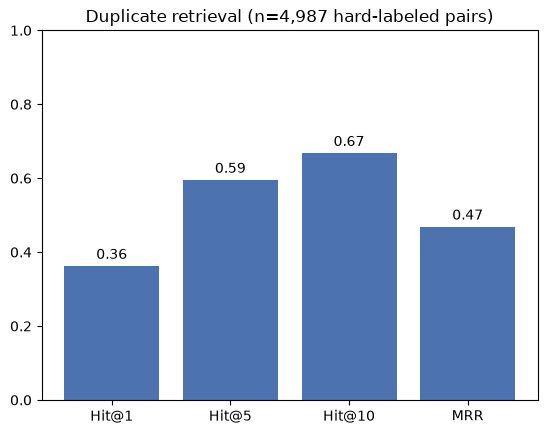

In [99]:
plt.bar([f"Hit@{k}" for k in KS] + ["MRR"], [hit[1], hit[5], hit[10], mrr], color="#4c72b0")
plt.ylim(0, 1); plt.title(f"Duplicate retrieval (n={usable:,} hard-labeled pairs)")
for i, v in enumerate([hit[1], hit[5], hit[10], mrr]): plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.show()

### Step 7 补充 · 切片诊断：检索在哪些主题 / 场景更难

headline 是全局平均，工程上更关心*它在哪里失败*。用 Step 3 的簇给每个重复对分组、再按"同组件 vs 跨组件"切开，
就能定位 hit rate 的天花板来自哪里，而不是只报一个平均数。

按主题切片（n≥50，共 16 个主题，Hit@10 升序）
  最难检索（bottom 3）：
    IP Protection Updates              Hit@10=0.42  MRR=0.35  n=50
    UI/UX Improvements                 Hit@10=0.52  MRR=0.36  n=332
    Security Vulnerabilities           Hit@10=0.52  MRR=0.37  n=386
  最易检索（top 3）：
    Single Tracking Bug                Hit@10=0.74  MRR=0.58  n=347
    Firefox Performance Issues         Hit@10=0.75  MRR=0.53  n=570
    Search Bar Focus                   Hit@10=0.81  MRR=0.56  n=312

同组件 vs 跨组件：
  same-component   Hit@10=0.72  MRR=0.52  n=3,225 (65%)
  cross-component  Hit@10=0.57  MRR=0.38  n=1,762 (35%)


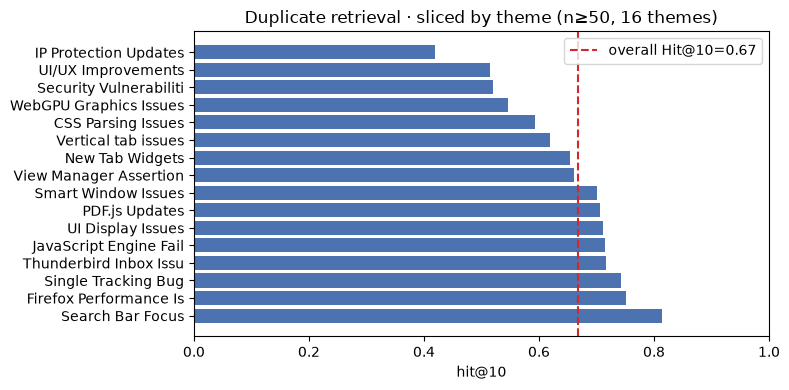

In [100]:
# 复用 Step 7 的检索，按 master 所在簇 & 是否跨组件切片
comp_arr = bugs["component"].astype(str).values
by_cluster = {}; by_cross = {True: [0, 0.0, 0], False: [0, 0.0, 0]}
for dup_id, master_id in pairs.itertuples(index=False, name=None):
    di, mi = str(dup_id), str(master_id)
    if di not in id_to_row or mi not in id_to_row:
        continue
    ri, rj = id_to_row[di], id_to_row[mi]
    sims = E @ E[ri]; sims[ri] = -np.inf
    rank = int(np.where(np.argsort(-sims) == rj)[0][0]) + 1
    h10 = int(rank <= 10)
    d = by_cluster.setdefault(labels[rj], [0, 0.0, 0])
    d[0] += h10; d[1] += 1.0 / rank; d[2] += 1
    key = comp_arr[ri] == comp_arr[rj]
    by_cross[key][0] += h10; by_cross[key][1] += 1.0 / rank; by_cross[key][2] += 1

rows_sl = [(names.get(c, str(c)), h / n, r / n, n) for c, (h, r, n) in by_cluster.items() if n >= 50]
rows_sl.sort(key=lambda x: x[1])
print(f"按主题切片（n≥50，共 {len(rows_sl)} 个主题，Hit@10 升序）")
print("  最难检索（bottom 3）：")
for name_, p, r, n in rows_sl[:3]:
    print(f"    {name_[:34]:<34} Hit@10={p:.2f}  MRR={r:.2f}  n={n}")
print("  最易检索（top 3）：")
for name_, p, r, n in rows_sl[-3:]:
    print(f"    {name_[:34]:<34} Hit@10={p:.2f}  MRR={r:.2f}  n={n}")
print("\n同组件 vs 跨组件：")
_tot = by_cross[True][2] + by_cross[False][2]
for key, nm in [(True, "same-component"), (False, "cross-component")]:
    h, r, n = by_cross[key]
    print(f"  {nm:<16} Hit@10={h/n:.2f}  MRR={r/n:.2f}  n={n:,} ({n/_tot:.0%})")

labs_s = [x[0][:22] for x in rows_sl]; vals_s = [x[1] for x in rows_sl]
plt.figure(figsize=(8, 4)); plt.barh(labs_s, vals_s, color="#4c72b0")
plt.gca().invert_yaxis(); plt.xlim(0, 1)
plt.axvline(hit[10], color="C3", ls="--", label=f"overall Hit@10={hit[10]:.2f}")
plt.xlabel("hit@10"); plt.title(f"Duplicate retrieval · sliced by theme (n≥50, {len(rows_sl)} themes)"); plt.legend(); plt.tight_layout(); plt.show()

## Step 8 · Readout

把上面每一步算出的数字拼成一页决策 memo，每条结论都可逐行辩护。

In [20]:
kappa_txt = "pending human labels" if kappa is None else f"{kappa:.3f}"
memo = [
    "# Bugzilla Defect Intelligence — Readout", "",
    "## Corpus",
    f"- {len(bugs):,} bugs (Firefox / Core / Thunderbird), {bugs.component.nunique()} components, {(bugs.desc_words>0).mean():.0%} with descriptions",
    f"- {usable:,} hard-labeled duplicate pairs for retrieval eval", "",
    "## Duplicate retrieval (semantic, hard labels) — headline",
    f"- hit@1={hit[1]:.3f}  hit@5={hit[5]:.3f}  hit@10={hit[10]:.3f}  MRR={mrr:.3f}",
    f"- reading: a duplicate's true master is surfaced in the top-10 {hit[10]:.0%} of the time", "",
    f"- ceiling: cross-component dups ({by_cross[False][2]/(by_cross[True][2]+by_cross[False][2]):.0%} of pairs) Hit@10={by_cross[False][0]/by_cross[False][2]:.2f} vs {by_cross[True][0]/by_cross[True][2]:.2f} within-component", "",
    "## Clustering (externally validated by dup labels)",
    f"- {best_k} themes; duplicate pairs land in the SAME cluster {same_cluster_rate:.0%} of the time (random {rand_same:.0%}, ×{same_cluster_rate/rand_same:.0f})", "",
    "## Extraction agent (LangGraph supervisor + tool loop)",
    f"- {len(sig)} distinct trajectories over {n} bugs; {zero_research_pct:.0%} solved with zero retrieval; mean {mean_steps:.1f} supervisor steps",
    f"- valid yield: first-pass {first_pass:.0%} -> after critique-retry {after_retry:.0%} (agent self-correction {after_retry-first_pass:+.0%})", "",
    "## Auto-rater reliability",
    f"- LLM-judge vs human Cohen's κ: {kappa_txt}", "",
    "## Themes (top, 95% Wilson CI)",
] + [f"- {t}: {sh:.1%} [{lo:.1%}, {hi:.1%}]" for t, c, sh, lo, hi in rows[:6]]
open("insights_memo.md", "w").write("\n".join(memo) + "\n")
print("\n".join(memo))

# Bugzilla Defect Intelligence — Readout

## Corpus
- 13,019 bugs (Firefox / Core / Thunderbird), 281 components, 93% with descriptions
- 4,987 hard-labeled duplicate pairs for retrieval eval

## Duplicate retrieval (semantic, hard labels) — headline
- hit@1=0.362  hit@5=0.595  hit@10=0.667  MRR=0.468
- reading: a duplicate's true master is surfaced in the top-10 67% of the time

- ceiling: cross-component dups (35% of pairs) Hit@10=0.57 vs 0.72 within-component

## Clustering (externally validated by dup labels)
- 18 themes; duplicate pairs land in the SAME cluster 72% of the time (random 6%, ×11)

## Extraction agent (LangGraph supervisor + tool loop)
- 18 distinct trajectories over 1762 bugs; 46% solved with zero retrieval; mean 5.4 supervisor steps
- valid yield: first-pass 58% -> after critique-retry 80% (agent self-correction +22%)

## Auto-rater reliability
- LLM-judge vs human Cohen's κ: 0.390

## Themes (top, 95% Wilson CI)
- Performance Issues Firefox: 9.7% [9.2%, 10.2%]
- Se

### 结语

整条链路跑通：加载 → embedding → 聚类主题 → 统计(Wilson CI) → 抽取 agent(工具调用 + MCP 接地) → auto-rater×κ → **去重检索(硬标签)** → readout。

**headline = 缺陷去重检索 hit@10 / MRR（真实 ground truth）+ LLM 抽取可信度校准（κ）。** 这是缺陷分诊 / 重复检测的工业级问题。开发稳定后，把这些函数收敛进 `pipeline.py`，`showcase.ipynb` 改成 `import pipeline` 直接调用即可。

**三步不是并列平铺，而是互相验证、汇入同一批硬标签**：embedding 是共享底座；Step 7 的 4,987 对重复硬标签**反向验证**了 Step 3 聚类的语义有效性（同簇率 ≈ 随机的 12 倍）；再用簇 + 结构化字段把去重**切片诊断**（跨组件重复是 Hit@10 天花板），并给每个簇画像。没有硬凑「用聚类提升检索排序」（试过，弱信号在强 baseline 上只会引入噪声），而是让各模块**交叉印证**。

In [21]:
print("development notebook complete")

development notebook complete
